In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from functions import F_P, GradientKernel,KernelGradientDiscrepancy
import jax_kernels as ker
from variational_inference import VariationalInference
import functions as f

import jax
from jax import random

In [2]:
device_name = "cpu"

In [3]:
c = 1
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y)))

def q_0(x):
    return jnp.exp(-jnp.linalg.norm(x)**2/2) #/ jnp.sqrt((2 *jnp.pi)**d)

def v(X):
    return -1/4 * jnp.linalg.norm(X, axis=1)**2 

def L(X):
    return jnp.mean(v(X))

k = jit(k)
q_0 = jit(q_0)
v = jit(v)
L = jit(L)


In [4]:
#eta = 0.1
T = 3000
d = 2

VI = VariationalInference(q_0,L,k,d,[3],"tanh")

# theta0 = flat_params
W0 = random.normal(random.PRNGKey(2), (1000, d))
#X0 = VI.model(Theta[0], W0)

key = random.PRNGKey(1)
Theta,_ = VI.run(T,key)
theta_fin = Theta[-1]

W_fin = random.normal(random.PRNGKey(2), (100, d))
X_fin = vmap(lambda w : VI.model_T(w))(W_fin)
#X = [VI.push_T_theta(theta, W0) for theta in Theta]

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [5]:
X_fin

Array([[-4.74655509e-01,  9.72290635e-01],
       [-2.58625656e-01,  2.22580862e+00],
       [ 9.59037423e-01,  1.22361112e+00],
       [-2.36339498e+00,  1.85557663e-01],
       [ 8.07441413e-01,  4.71813917e-01],
       [-1.30459654e+00,  7.71030009e-01],
       [-1.17813385e+00, -1.05549705e+00],
       [-6.80334151e-01,  2.54006028e-01],
       [ 3.58084321e-01, -1.22893846e+00],
       [ 1.79240525e+00, -8.27656209e-01],
       [ 1.23587215e+00, -4.70279396e-01],
       [-1.32013905e+00, -8.82623315e-01],
       [-1.29496205e+00,  8.29310477e-01],
       [-5.50671995e-01,  2.15371180e+00],
       [ 1.49975562e+00,  4.65812862e-01],
       [-4.19964433e-01,  1.83693364e-01],
       [-2.87446380e-01,  2.12440348e+00],
       [ 2.14654708e+00,  3.60125184e-01],
       [-2.15826821e+00, -1.95473954e-01],
       [ 2.40254498e+00,  9.33878303e-01],
       [ 1.10890818e+00,  9.95648146e-01],
       [-3.97268891e-01, -2.20484996e+00],
       [-1.43678442e-01, -1.48596203e+00],
       [-4.

In [6]:
# F_P = f.F_P(q_0, L)
# k_pq = f.GradientKernel(VI.S_PQ,k)
# KGD = f.KernelGradientDiscrepancy(k_pq)

# KGD_fin = jnp.zeros(T)
# # # KDE_KGD_fin = jax.device_put(jnp.zeros(len(Eta)), device)
# # # F_P_fin = jax.device_put(jnp.zeros(len(Eta)), device)
# # # L_fin = jax.device_put(jnp.zeros(len(Eta)), device)

# for it in range(T):
#     KGD_fin = KGD_fin.at[it].set(KGD.evaluate(X[it]))
# #     # KDE_KGD_fin = KDE_KGD_fin.at[e].set(KGD.kde_KGD(X,num_samples = 300))
# #     # F_P_fin = F_P_fin.at[e].set(F_P.evaluate(X,num_samples = 300))
# #     # L_fin = L_fin.at[e].set(L(X))
    

In [7]:
# plt.plot(KGD_fin)

/var/folders/zl/0c18q_l567xgnm85cwp5t7xm0000gp/T/ipykernel_1722/3605247608.py:38: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X, Y, Z, levels=10, cmap='viridis', alpha=0.7, label='Gaussian contours')


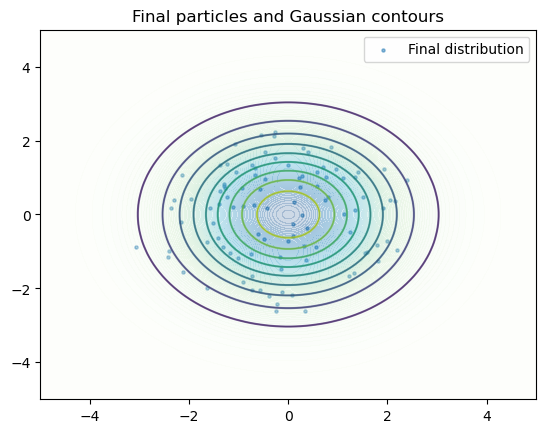

In [8]:
plt.scatter(X_fin[:, 0], X_fin[:, 1], s=5, alpha=0.5,label='Final distribution')
#plt.scatter(X0[:, 0], X0[:, 1], s=1, alpha=0.5,label = 'Initial distribution')
plt.legend()

import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax.scipy.stats import multivariate_normal

# Paramètres de la distribution
mean = jnp.zeros(2)  # Moyenne (0, 0)
cov = jnp.eye(2) * 2.0  # Matrice de covariance (2 * identité)

# Grille pour les lignes de niveau
x = jnp.linspace(-5, 5, 100)
y = jnp.linspace(-5, 5, 100)
X, Y = jnp.meshgrid(x, y)
pos = jnp.dstack((X, Y))
Z = multivariate_normal.pdf(pos, mean=mean, cov=cov)

cf = plt.contourf(
        X, Y, Z, 
        levels=100,          # plus de niveaux pour un dégradé lisse
        cmap='GnBu', 
        alpha=0.2     # transparence du fond
    )

  # Lignes de contour par-dessus
plt.contour(
    X, Y, Z, 
    levels=10, 
    colors='black', 
    linewidths=0.8,
    alpha=0.5)
# Calcul de la densité de probabilité
Z = multivariate_normal.pdf(pos, mean, cov)

# 
plt.contour(X, Y, Z, levels=10, cmap='viridis', alpha=0.7, label='Gaussian contours')
plt.title("Final particles and Gaussian contours")
plt.legend()
plt.show()

# 4 MFNN 
Here we consider random variables linked by the relation $y,z \in \mathbb{R}$ .$y = sin(z) + \varepsilon$ where $\varepsilon$ is a gaussian noise. Consider $N$ observations pf $(z,y)$, $(Z_1,Y_1),...,(Z_N,Y_N)$. $\mathcal{L} (Q) = \frac1N \sum_{i=1}^N (Y_i - \mathbb{E}_{X \sim Q} [\psi(X,Z)])^2$. The learning function $\psi$ is a two layer neural network with parameter $X$. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
#from mfld import MeanFieldLangevinDynamics
import jax_kernels as ker
import functions as f
import time
from variational_inference import VariationalInference

import jax.numpy as jnp
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
import random
import jax
from jax import random

from jax.flatten_util import ravel_pytree
from jax import grad, random,vmap,tree_util

In [2]:
device_name = "cpu"

In [30]:

def generate_data(key, s, N, noise_std=0.1):
    key_z, key_noise = random.split(key)
    
    Z = random.uniform(key_z, (N, s),minval = 0,maxval=1.0)  # uniform distribution [-1,1]

    #explanation function
    def f(z):
        return jnp.sin(2 * jnp.pi * z[:,0])#, 0]) + 0.5 * Z[:, 1]**2 - jnp.exp(-Z[:, 2])

    Y_clean = f(Z)

    # noise
    noise = noise_std * random.normal(key_noise, shape=Y_clean.shape)
    Y= Y_clean + noise

    return Z, Y

N = 300
s=1 #input dimension 
key_data = random.PRNGKey(8)
Z,Y = generate_data(key_data,s, N, noise_std=0.1) # put more noise
#plt.plot(Z,Y,".")


In [40]:
kernel_name = "IMQ"
c = jnp.array(1.0)
b = 1/2.0
def k(x,y):
    return (c**2 + (x-y).dot(x-y))**(-b)
    #return jnp.dot(x,y)
# scale = 1
# k = lambda x, y: jnp.exp(-((x-y).dot(x-y)/scale**2))

def q_0(x):
    d = jax.lax.stop_gradient(len(x))
    return jnp.exp(-jnp.dot(x,x)/(2*4)) #/ jnp.sqrt((2 * jnp.pi)**d)


def esp_forward(X, z):
    E = jnp.mean(jit(vmap(lambda x : model.apply(unravel_fn(x), z)))(X))
    return E
gamma = 10
def L(X):  
    n = len(X)
    Esp_forward = vmap(lambda z: esp_forward(X, z))(Z)  
    return gamma * jnp.mean((Esp_forward - Y) ** 2) 


key = random.PRNGKey(0)
hidden_dim = 2
model = f.MLP(hidden_dims=[hidden_dim], output_dim=1)

params = model.init(key, jnp.ones((s,)))  
flat_params, unravel_fn = ravel_pytree(params)
d = len(flat_params)  


k = jit(k)
q_0 = jit(q_0)
esp_forward = jit(esp_forward)
L = jit(L)  
 
learning_rate = 1e-5
VI = VariationalInference(q_0, L, k, d,[20,20],"elu", learning_rate) 

In [44]:
T = 1000
n = 100


key = random.PRNGKey(1)
Theta,Loss = VI.run(T,key,1000)
theta_fin = Theta[-1]

W_fin = random.normal(random.PRNGKey(2), (100, d))
X_fin = vmap(lambda w : VI.model_T(w))(W_fin)

0
100
200
300
400
500
600
700
800
900


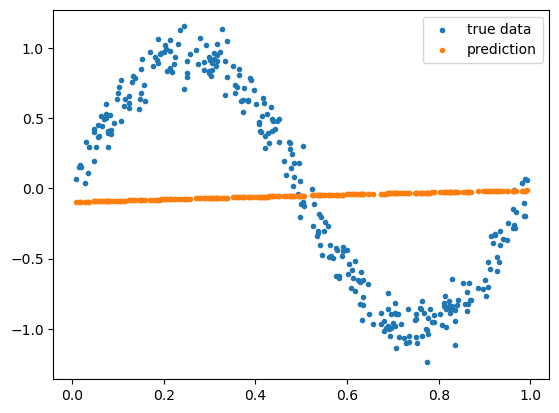

In [45]:
plt.figure()
plt.scatter(Z,Y,label = "true data",marker = ".")
Y_hat = vmap(lambda z : esp_forward(X_fin, z))(Z)
plt.scatter(Z,Y_hat,label = "prediction",marker = ".")
plt.legend()



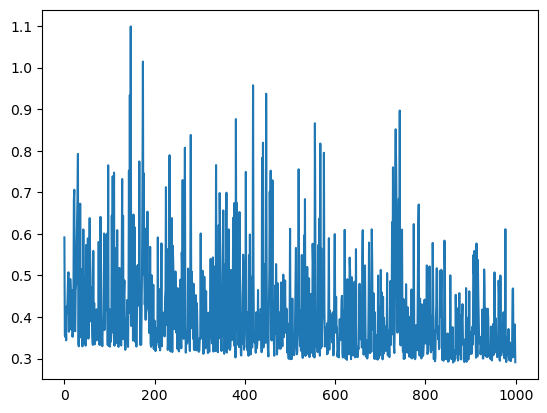

In [46]:
plt.plot(Loss)

In [26]:
F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(VI.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

In [27]:

# W0 = random.normal(random.PRNGKey(2), (1000, d))
# X = vmap(lambda w : VI.model_T(w))(W0)
# KGD_values = jnp.zeros(T)
# F_P_values = jnp.zeros(T)
# for it in range(T):
#     KGD_values = KGD_values.at[it].set(KGD.evaluate(X[it]))
#     F_P_values = F_P_values.at[0].set(F_P.evaluate(X[it]))
# plt.plot(KGD_values, label='KGD values')
# plt.figure()
# plt.plot(F_P_values, label='F_P values')